**Running several sections at once.** `run_sections(3, 4, 5, 6, 7, 8)` runs the code cells of those sections in order, so you don't have to click each one. Put the call in a new cell anywhere, e.g. at the bottom, and run that cell. It stops at the first cell that fails. Include section 3 whenever you changed a setting, otherwise the old settings are used.*italicized text*


=== section 3: TRAIN_BANDS = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08",

=== section 4: X = np.load(X_PATH)              # (27000, 64, 64, 13) uint16, channel
train: (27000, 64, 64, 13) uint16 | test: (4232, 64, 64, 12) uint16
classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
images per class: {'AnnualCrop': 3000, 'Forest': 3000, 'HerbaceousVegetation': 3000, 'Highway': 2500, 'Industrial': 2500, 'Pasture': 2000, 'PermanentCrop': 2500, 'Residential': 3000, 'River': 2500, 'SeaLake': 3000}

=== section 4: def sample_idx(n_total, n=2000, seed=SEED):


,train mean,test mean,train std,test std,train min,test min
B01,1350.699951,381.000000,247.899994,324.399994,829.0,1.0
B02,1116.099976,404.000000,344.600006,414.799988,1.0,0.0
B03,1042.099976,627.700012,406.700012,491.799988,1.0,0.0
B04,948.700012,577.900024,606.099976,601.099976,1.0,0.0
B05,1201.000000,921.200012,579.200012,660.299988,184.0,5.0
B06,1997.599976,1804.900024,872.500000,1184.300049,159.0,1.0
B07,2365.300049,2092.899902,1099.599976,1416.300049,129.0,1.0
B08,2292.300049,2180.399902,1131.800049,1518.699951,0.0,0.0
B8A,2588.800049,2251.199951,1247.199951,1521.699951,95.0,1.0
B09,730.799988,2237.300049,405.600006,1470.800049,44.0,1.0



=== section 4: plt.figure(figsize=(9, 3.5))


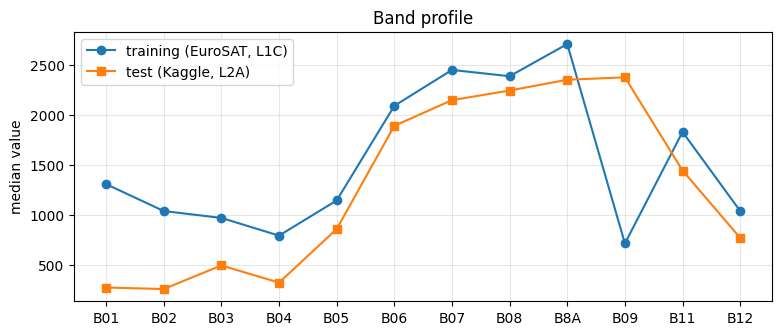


=== section 4: def to_rgb(img, band_names):


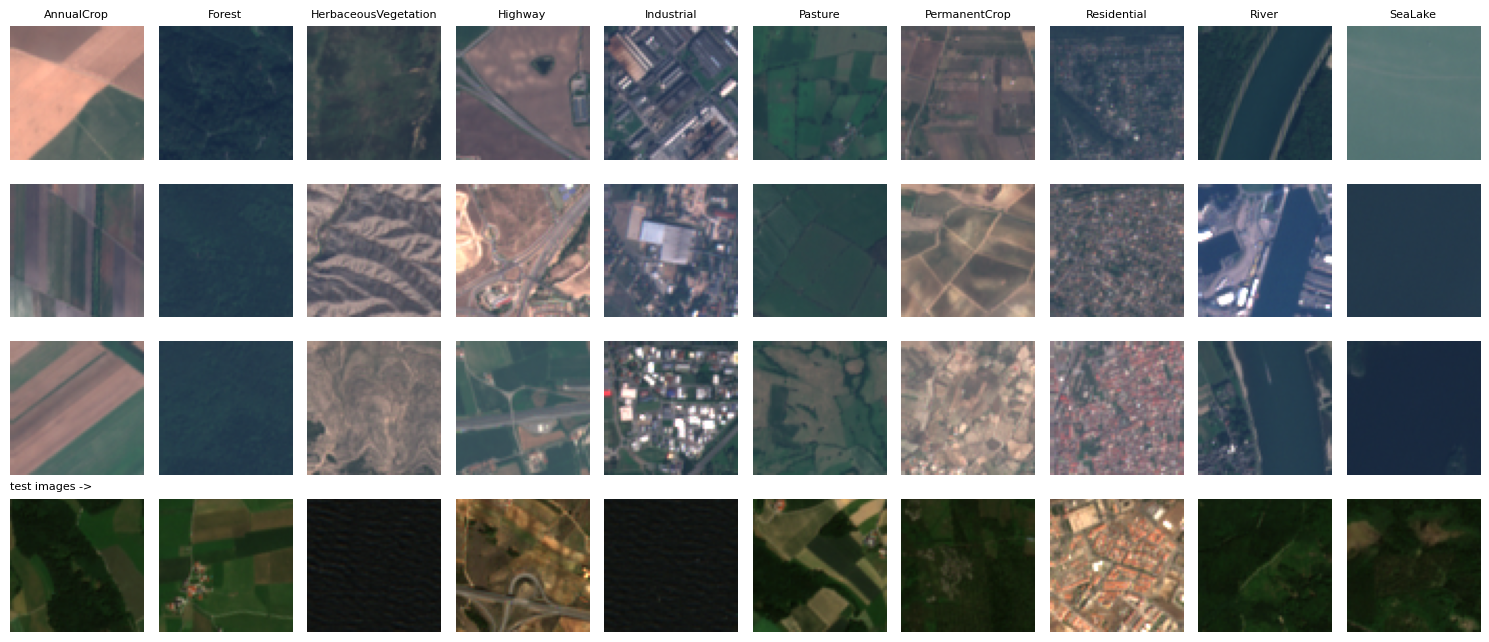


=== section 5: from sklearn.model_selection import train_test_split
train 21600 | val 5400 | test 4232

=== section 6: class EuroSATDataset(Dataset):
one batch: (128, 12, 64, 64) torch.float32 | mean -0.05, std 0.98

=== section 7: def conv_block(c_in, c_out, n_convs):
588,042 parameters
output shape for 2 images: (2, 10)

=== section 8: def run_epoch(model, loader, loss_fn, optimizer=None):

=== section 8: RUN_DIR = DATA_DIR / "runs" / RUN_NAME
epoch  1 | train loss 0.589 acc 0.801 | val loss 0.347 acc 0.884 | 19s  <- best so far, saved
epoch  2 | train loss 0.331 acc 0.890 | val loss 0.326 acc 0.889 | 19s  <- best so far, saved
epoch  3 | train loss 0.272 acc 0.909 | val loss 0.271 acc 0.912 | 21s  <- best so far, saved
epoch  4 | train loss 0.246 acc 0.919 | val loss 0.196 acc 0.935 | 18s  <- best so far, saved
epoch  5 | train loss 0.218 acc 0.925 | val loss 0.153 acc 0.946 | 19s  <- best so far, saved
epoch  6 | train loss 0.198 acc 0.934 | val loss 0.153 acc 0.947 | 21s  <- best

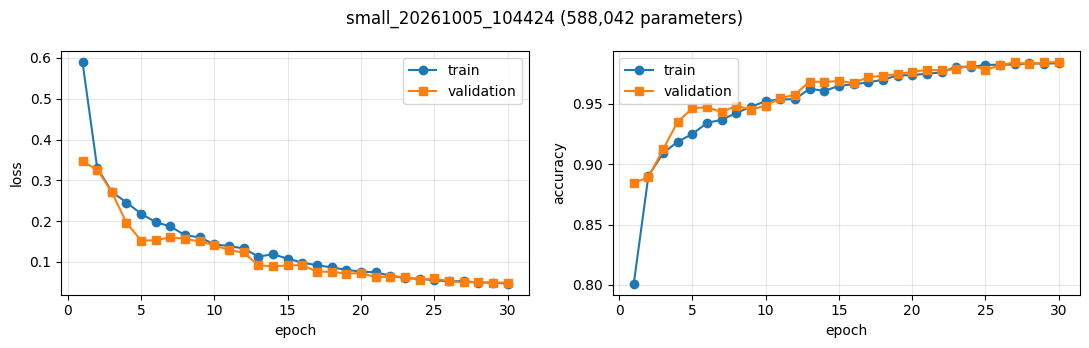


=== section 10: from sklearn.metrics import ConfusionMatrixDisplay
validation accuracy (best checkpoint, TTA): 0.9856


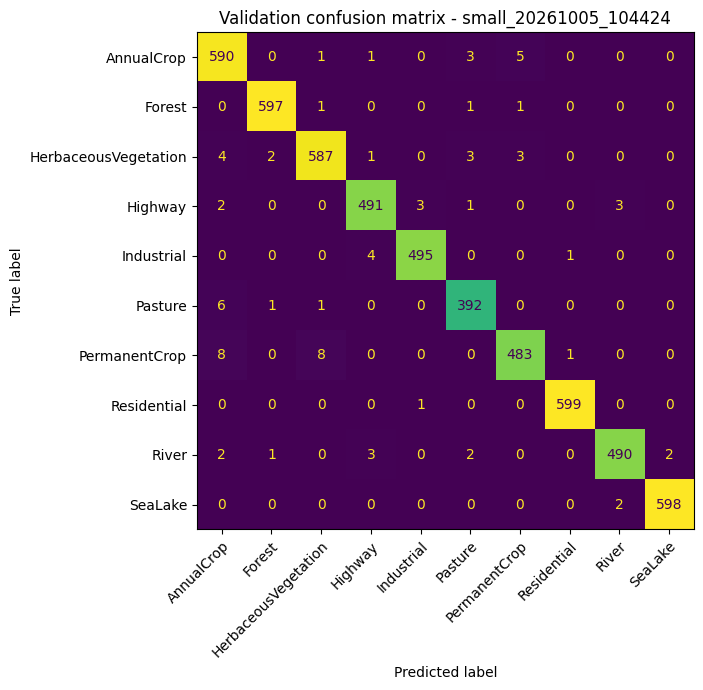


=== section 11: def make_submission(model, loader, tta):
format matches sample_submission.csv
saved /content/drive/MyDrive/eurosat/runs/small_20261005_104424/submission_small.csv
label
SeaLake                 1036
PermanentCrop            814
Forest                   443
Highway                  365
Industrial               359
Pasture                  341
HerbaceousVegetation     282
Residential              268
River                    188
AnnualCrop               136
Name: count, dtype: int64

=== section 12: SUBMIT = True   # set True to upload this run's CSV
12 submissions remaining today.
Successfully submitted to 7,854,1.00: Machine Learning 2026 - Coding challenge 
  0%|          | 0.00/62.7k [00:00<?, ?B/s]
100%|██████████| 62.7k/62.7k [00:00<00:00, 75.1kB/s]

logged to /content/drive/MyDrive/eurosat/experiment_log.csv

=== section 13: def reproduce_submission(run_dir):


BadZipFile: Bad offset for central directory

RuntimeError: stopped: a cell in section 13 failed (see the error above)

In [5]:
import sys

IN_COLAB = "google.colab" in sys.modules
def run_sections(*numbers):
    # Run the code cells of the given sections in notebook order, e.g. run_sections(3, 4, 5, 6, 7, 8).
    if IN_COLAB:                                        # the cells as they are in the editor, unsaved edits included
        from google.colab import _message
        cells = _message.blocking_request("get_ipynb", timeout_sec=30)["ipynb"]["cells"]
    else:                                               # elsewhere: the last saved version on disk
        path = globals().get("__vsc_ipynb_file__", "small_track_colab.ipynb")
        cells = json.loads(Path(path).read_text())["cells"]
    section = None
    for cell in cells:
        src = "".join(cell["source"])
        heading = re.match(r"##\s*(\d+)\.", src)        # section headings look like "## 4. Load ..."
        if cell["cell_type"] == "markdown" and heading:
            section = int(heading.group(1))
        # Cells mentioning run_sections( are skipped, so a call can never run itself.
        elif cell["cell_type"] == "code" and section in numbers and src.strip() and "run_sections(" not in src:
            print(f"\n=== section {section}: {src.strip().splitlines()[0][:70]}")
            if not get_ipython().run_cell(src).success:
                raise RuntimeError(f"stopped: a cell in section {section} failed (see the error above)")



run_sections(3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13)   # settings -> data -> split -> loaders -> model -> training

# Small Track (≤ 1M parameters) — EuroSAT Coding Challenge

A starter notebook for the **small track** of the ML coding challenge. It runs from start to finish: data → model → training → evaluation → Kaggle CSV. The section numbers in brackets, e.g. *(guide Step 3)*, refer to `claude_guide/coding_challenge_guide.pdf`, which explains the *why* behind each part.

**Course tools.** Where the course labs (`ML2026-Lab/`) cover a step, this notebook uses the same tools: `rasterio` to read the EuroSAT GeoTIFFs and percentile scaling for display (`cc_1`), scikit-learn's `train_test_split`, `metrics.accuracy_score`, `classification_report` and `confusion_matrix` with a seaborn heatmap (Lab 2). The PyTorch parts (Sections 6–8) will be aligned with Labs 3–4 (PyTorch, custom datasets, CNNs) once they are published.

### How to use it
1. **Open in Colab.** In Colab choose *File → Upload notebook* and pick this file, then *File → Save a copy in Drive* so your edits are kept.
2. **Turn on the GPU.** Choose *Runtime → Change runtime type → T4 GPU*.
3. **Kaggle token.** In the left sidebar, open the key icon (*Secrets*), add a secret named `KAGGLE_API_TOKEN` with your token as its value, and enable *Notebook access*.
4. **Run the cells from top to bottom.** Sections 1 and 2 download data once and save it to your Drive (`MyDrive/eurosat/`). On later sessions they notice the saved files and skip themselves.

### Two kinds of markers
- **CHECK** — look at the output and confirm it makes sense before going on.
- **CHOOSE** — a setting you are meant to experiment with.

### The first run is a smoke test
`SMOKE_TEST = True` (Section 3) trains on a tiny subset for 2 epochs. It exists to find bugs quickly, **not** to get a score. Once everything runs, set it to `False` and run again.

## 0. Setup
Imports, Google Drive, GPU check, random seed.

**Why Drive?** Colab's own disk (`/content`) is **wiped whenever the session ends**. Anything that must survive — the cached dataset, model weights, CSV files — goes to `MyDrive/eurosat/`.

In [1]:
import os, io, re, sys, json, time, random, shutil, hashlib, zipfile, subprocess, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = Path("/content/drive/MyDrive/eurosat")  # survives disconnects
    WORK_DIR = Path("/content/work")                   # fast, but wiped when the session ends
else:                                                  # running outside Colab (e.g. locally)
    DATA_DIR = Path(os.environ.get("EUROSAT_DATA_DIR", "eurosat"))
    WORK_DIR = Path(os.environ.get("EUROSAT_WORK_DIR", "work"))
DATA_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)

COMPETITION = "7-854-1-00-machine-learning-2026-coding-challenge"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cpu":
    print("WARNING: no GPU. In Colab: Runtime -> Change runtime type -> T4 GPU, then run again.")

def set_seed(seed):
    # Same seed -> same split, same starting weights, same shuffling -> repeatable runs.
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def save_npz(path, **arrays):
    # np.savez straight onto the Drive mount can corrupt the file (zip writing jumps back to fill in
    # headers), so build the .npz in memory and write it in one go.
    buf = io.BytesIO()
    np.savez(buf, **arrays)
    Path(path).write_bytes(buf.getvalue())

SEED = 42
set_seed(SEED)

Mounted at /content/drive
device: cuda


## 1. EuroSAT: download once, cache on Drive *(guide Step 1)*
This downloads `EuroSAT_MS.zip` (2.1 GB, all 13 bands) from Zenodo. It checks the file is not corrupted and unpacks it. Then it saves all 27,000 images as **one** NumPy file on Drive: `X_ms.npy` (≈ 2.9 GB, raw `uint16` values), plus `y.npy` (labels 0–9) and `classes.json` (label number → class name).

Loading one big `.npy` takes about a minute; unpacking 27,000 small `.tif` files every session would take much longer. **This cell takes a while the first time (download + unpacking) and skips itself afterwards.**

What we know about the files (checked on samples from the real zip): each image is `(64, 64, 13)` `uint16`. The bands are on the **last** axis ("channel-last"). The files are read with `rasterio` and `reshape_as_image`, as in the course's `cc_1` notebook.

In [2]:
X_PATH, Y_PATH, CLASSES_PATH = DATA_DIR / "X_ms.npy", DATA_DIR / "y.npy", DATA_DIR / "classes.json"
EUROSAT_URL = "https://zenodo.org/records/7711810/files/EuroSAT_MS.zip?download=1"
EUROSAT_MD5 = "091174add3c8e680a49244acf185b9f0"

def md5sum(path, chunk=1 << 20):
    # Fingerprint of a file; if it differs from the published one, the download is broken.
    h = hashlib.md5()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

def download(url, dest, attempts=3):
    # Zenodo occasionally answers with a temporary error, so try a few times.
    for k in range(1, attempts + 1):
        try:
            urllib.request.urlretrieve(url, dest)
            return
        except Exception as e:
            print(f"download attempt {k} failed: {e}")
            time.sleep(10)
    raise RuntimeError("download failed - try again in a few minutes")

def read_tif(path):
    # One EuroSAT GeoTIFF -> (64, 64, 13) array, read with rasterio as in the course's cc_1 notebook.
    import rasterio as rio
    from rasterio.plot import reshape_as_image
    with rio.open(path, "r") as d:
        return reshape_as_image(d.read())       # rasterio reads (bands, H, W); reshape_as_image -> (H, W, bands)

def build_eurosat_cache():
    # Download EuroSAT_MS.zip, unpack it, and save all images as one uint16 array on Drive.
    try:
        import rasterio
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rasterio"], check=True)
    zip_path = WORK_DIR / "EuroSAT_MS.zip"
    if not zip_path.exists():
        print("downloading EuroSAT_MS.zip (2.1 GB) ...")
        download(EUROSAT_URL, zip_path)
    print("checking the download ...")
    if md5sum(zip_path) != EUROSAT_MD5:
        zip_path.unlink()
        raise RuntimeError("download corrupted (checksum mismatch) - run this cell again")
    print("unpacking ...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(WORK_DIR)
    root = WORK_DIR / "EuroSAT_MS"
    classes = sorted(p.name for p in root.iterdir() if p.is_dir())
    files = [(f, i) for i, c in enumerate(classes) for f in sorted((root / c).glob("*.tif"))]
    first = read_tif(files[0][0])
    print(f"{len(files)} images, each {first.shape} {first.dtype}")
    X = np.empty((len(files),) + first.shape, dtype=first.dtype)   # allocate once, fill in place
    for k, (f, _) in enumerate(files):
        X[k] = read_tif(f)
    y = np.array([i for _, i in files], dtype=np.int64)
    print("saving to Drive (takes a few minutes) ...")
    np.save(X_PATH, X)
    np.save(Y_PATH, y)
    CLASSES_PATH.write_text(json.dumps(classes))

if X_PATH.exists() and Y_PATH.exists() and CLASSES_PATH.exists():
    print("EuroSAT cache found on Drive - nothing to do.")
else:
    build_eurosat_cache()
    print("done.")

EuroSAT cache found on Drive - nothing to do.


## 2. Kaggle test data: download once, cache on Drive
This uses the Kaggle command-line tool with the token from Colab *Secrets* (see "How to use it" above).

- **403 / Forbidden:** you have not accepted the competition rules yet. Open the competition page, join it or accept the rules, then run again.
- **401 / Unauthorized:** the token is wrong. Make a new one in Kaggle *Settings → API*.

The slides say only "npy files" and do not describe their layout, so `load_test_arrays` handles the two usual cases:
- **one** `.npy` holding all images;
- **one `.npy` per image**, with the id as a number in the file name (e.g. `test_17.npy` → id 17).

It also detects whether the 12 bands are on the first or the last axis, and converts to channel-last like the training data. **CHECK** the printed listing and shapes. If the layout is something else, adapt this function. The data description on Kaggle's *Data* tab tells you what the files are.

In [3]:
XTEST_PATH, TESTIDS_PATH = DATA_DIR / "X_test.npy", DATA_DIR / "test_ids.npy"
KAGGLE_ZIP = DATA_DIR / f"{COMPETITION}.zip"

def kaggle(*args):
    # Run the Kaggle command-line tool, print its output, stop on errors.
    r = subprocess.run([sys.executable, "-m", "kaggle", *args], capture_output=True, text=True)
    print(r.stdout[-3000:], r.stderr[-3000:])
    r.check_returncode()

def setup_kaggle():
    # Install/upgrade the Kaggle CLI (token support needs a recent version) and pass it the token.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "kaggle"], check=True)
    if IN_COLAB and "KAGGLE_API_TOKEN" not in os.environ:
        from google.colab import userdata
        os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

def to_channel_last(a):
    # Accept (..., 12, 64, 64) or (..., 64, 64, 12); return (..., 64, 64, 12).
    if a.shape[-1] == 12:
        return a
    if a.shape[-3] == 12:
        return np.moveaxis(a, -3, -1)
    raise ValueError(f"cannot find the 12-band axis in shape {a.shape}")

def load_test_arrays(folder):
    # Return (images as (N, 64, 64, 12), ids as (N,)) from the unpacked Kaggle files.
    files = sorted(Path(folder).rglob("*.npy"))
    shapes = {f.name: np.load(f, mmap_mode="r").shape for f in files[:5]}
    print(f"{len(files)} .npy files, e.g.:", shapes)
    if len(files) == 1:                                     # case 1: all images in one file
        X_test = to_channel_last(np.load(files[0]))
        ids = np.arange(len(X_test))                        # CHECK: row order = test_id order?
    else:                                                   # case 2: one file per image
        number = lambda f: int(re.findall(r"\d+", f.stem)[-1])
        files = sorted(files, key=number)
        X_test = np.stack([to_channel_last(np.load(f)) for f in files])
        ids = np.array([number(f) for f in files])
    assert X_test.ndim == 4 and X_test.shape[1:] == (64, 64, 12), X_test.shape
    return X_test, ids

if XTEST_PATH.exists() and TESTIDS_PATH.exists():
    print("test cache found on Drive - nothing to do.")
else:
    if not KAGGLE_ZIP.exists():
        setup_kaggle()
        kaggle("competitions", "download", "-c", COMPETITION, "-p", str(DATA_DIR))
    raw = WORK_DIR / "kaggle_data"
    with zipfile.ZipFile(KAGGLE_ZIP) as z:
        z.extractall(raw)
        print("zip contents:", z.namelist()[:10], "..." if len(z.namelist()) > 10 else "")
    for csv in raw.rglob("*.csv"):                          # e.g. sample_submission.csv
        shutil.copy(csv, DATA_DIR / csv.name)
    X_test, test_ids = load_test_arrays(raw)
    np.save(XTEST_PATH, X_test)
    np.save(TESTIDS_PATH, test_ids)
    print("cached", X_test.shape, X_test.dtype)

test cache found on Drive - nothing to do.


## 3. Settings *(guide Steps 3, 6, 8)*
All the knobs of a run live in this one cell, so every experiment is a change here. The cell is saved with each run (`config.json`).

**Band order.** The model must see the **same bands in the same order** for training and test *(guide §1.4)*.
- `TRAIN_BANDS` is the order in the EuroSAT files. It was checked on samples from the real zip: the band at position 10 is near zero (B10, cirrus), and the **last** band is bright for vegetation (B8A, stored last — not after B08). The course's `cc_1` notebook lists B8A after B08; the data says otherwise, so keep this order.
- `TEST_BANDS` is the order in the Kaggle files. **CHECK** it against the Kaggle data description and against the band-profile plot in Section 4. The standard Sentinel-2 order without B10 is assumed here.
- `USE_BANDS` lists the bands the model actually uses. **CHOOSE**: removing bands (e.g. `"B01"`, `"B09"`) is one of the domain-shift experiments.

In [ ]:
TRAIN_BANDS = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B09", "B10", "B11", "B12", "B8A"]
TEST_BANDS  = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"]  # CHECK
USE_BANDS   = list(TEST_BANDS)                           # CHOOSE: e.g. drop "B01", "B09"

KEEP_TRAIN = [TRAIN_BANDS.index(b) for b in USE_BANDS]   # positions to take from EuroSAT images
KEEP_TEST  = [TEST_BANDS.index(b) for b in USE_BANDS]    # positions to take from test images

NORM_MODE   = "separate"   # CHOOSE: "train"    = test images standardised with EuroSAT statistics
                        #         "separate" = test images standardised with their own statistics
TEST_OFFSET = 0         # CHOOSE: 1000 if Section 4 shows test values shifted up by ~1000 (guide Step 2)

WIDTHS  = (32, 64, 128, 256)   # channels per block    (CHOOSE, but stay <= 1M parameters)
CONVS   = (2, 2, 2, 1)         # convolutions per block
DROPOUT = 0.3

EPOCHS       = 30
BATCH_SIZE   = 128
LR           = 1e-3
WEIGHT_DECAY = 1e-4
AUG_RADIOMETRIC = True  # CHOOSE: random per-band brightness jitter (targets the domain shift)
USE_TTA         = True   # average predictions over 8 flips/rotations (adds no parameters)

SMOKE_TEST  = False       # True = tiny 2-epoch run to catch bugs; set False for a real run
NUM_WORKERS = 2
RUN_NAME = time.strftime("small_%Y%m%d_%H%M%S") + ("_smoke" if SMOKE_TEST else "")

## 4. Load and look at the data *(guide Step 2)*
Loading `X_ms.npy` from Drive takes about a minute. Everything is loaded into RAM (≈ 3.7 GB in total), which the free Colab machine can hold.

In [ ]:
X = np.load(X_PATH)              # (27000, 64, 64, 13) uint16, channel-last
y = np.load(Y_PATH)              # (27000,) labels 0..9
CLASSES = json.loads(CLASSES_PATH.read_text())
X_test = np.load(XTEST_PATH)     # (N, 64, 64, 12), channel-last
test_ids = np.load(TESTIDS_PATH)

print("train:", X.shape, X.dtype, "| test:", X_test.shape, X_test.dtype)
print("classes:", CLASSES)
print("images per class:", dict(zip(CLASSES, np.bincount(y).tolist())))

train: (27000, 64, 64, 13) uint16 | test: (4232, 64, 64, 12) uint16
classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
images per class: {'AnnualCrop': 3000, 'Forest': 3000, 'HerbaceousVegetation': 3000, 'Highway': 2500, 'Industrial': 2500, 'Pasture': 2000, 'PermanentCrop': 2500, 'Residential': 3000, 'River': 2500, 'SeaLake': 3000}


**CHECK — per-band statistics, training vs. test.** This is your first look at the domain shift *(guide §1.4)*. Values are raw reflectance × 10,000. Look for bands whose test mean is very different from the training mean. A test minimum around 1000 everywhere, including water pixels, would suggest the `TEST_OFFSET` issue.

In [ ]:
def sample_idx(n_total, n=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    return np.sort(rng.choice(n_total, size=min(n, n_total), replace=False))

TO_TEST_ORDER = [TRAIN_BANDS.index(b) for b in TEST_BANDS]
tr = X[sample_idx(len(X))][..., TO_TEST_ORDER].astype(np.float32)
te = X_test[sample_idx(len(X_test))].astype(np.float32)
stats = pd.DataFrame({
    "train mean": tr.mean(axis=(0, 1, 2)), "test mean": te.mean(axis=(0, 1, 2)),
    "train std": tr.std(axis=(0, 1, 2)),   "test std": te.std(axis=(0, 1, 2)),
    "train min": tr.min(axis=(0, 1, 2)),   "test min": te.min(axis=(0, 1, 2)),
}, index=TEST_BANDS).round(1)
display(stats)

,train mean,test mean,train std,test std,train min,test min
B01,1350.699951,381.000000,247.899994,324.399994,829.0,1.0
B02,1116.099976,404.000000,344.600006,414.799988,1.0,0.0
B03,1042.099976,627.700012,406.700012,491.799988,1.0,0.0
B04,948.700012,577.900024,606.099976,601.099976,1.0,0.0
B05,1201.000000,921.200012,579.200012,660.299988,184.0,5.0
B06,1997.599976,1804.900024,872.500000,1184.300049,159.0,1.0
B07,2365.300049,2092.899902,1099.599976,1416.300049,129.0,1.0
B08,2292.300049,2180.399902,1131.800049,1518.699951,0.0,0.0
B8A,2588.800049,2251.199951,1247.199951,1521.699951,95.0,1.0
B09,730.799988,2237.300049,405.600006,1470.800049,44.0,1.0


**CHECK — band profile.** For each band, the median value over many images, training vs. test, in the assumed `TEST_BANDS` order.
- The absolute levels may differ; that is the domain shift.
- The **shape** should be similar: both curves rise strongly into the near-infrared bands (B06–B8A), because vegetation is very bright there, and fall again at B11/B12.
- A spike or dip in one curve that the other doesn't have, especially around B08/B8A/B09, suggests the assumed test band order is wrong.

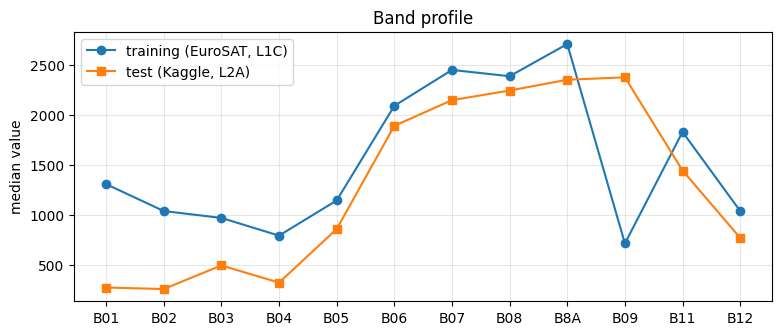

In [ ]:
plt.figure(figsize=(9, 3.5))
plt.plot(TEST_BANDS, np.median(tr, axis=(0, 1, 2)), "o-", label="training (EuroSAT, L1C)")
plt.plot(TEST_BANDS, np.median(te, axis=(0, 1, 2)), "s-", label="test (Kaggle, L2A)")
plt.ylabel("median value"); plt.title("Band profile"); plt.legend(); plt.grid(alpha=0.3)
plt.show()
del tr, te

**CHECK — pictures.** RGB composites (bands B04, B03, B02). For display only, each band is stretched between its 2nd and 98th percentile with `normalize_for_display` from the course's `cc_1` notebook. This hides brightness differences, so judge the domain shift with the statistics and the band profile above; here, check that training and test images both look like normal aerial photos. If the test images look strange (e.g. purple or green), the assumed test band order is probably wrong.

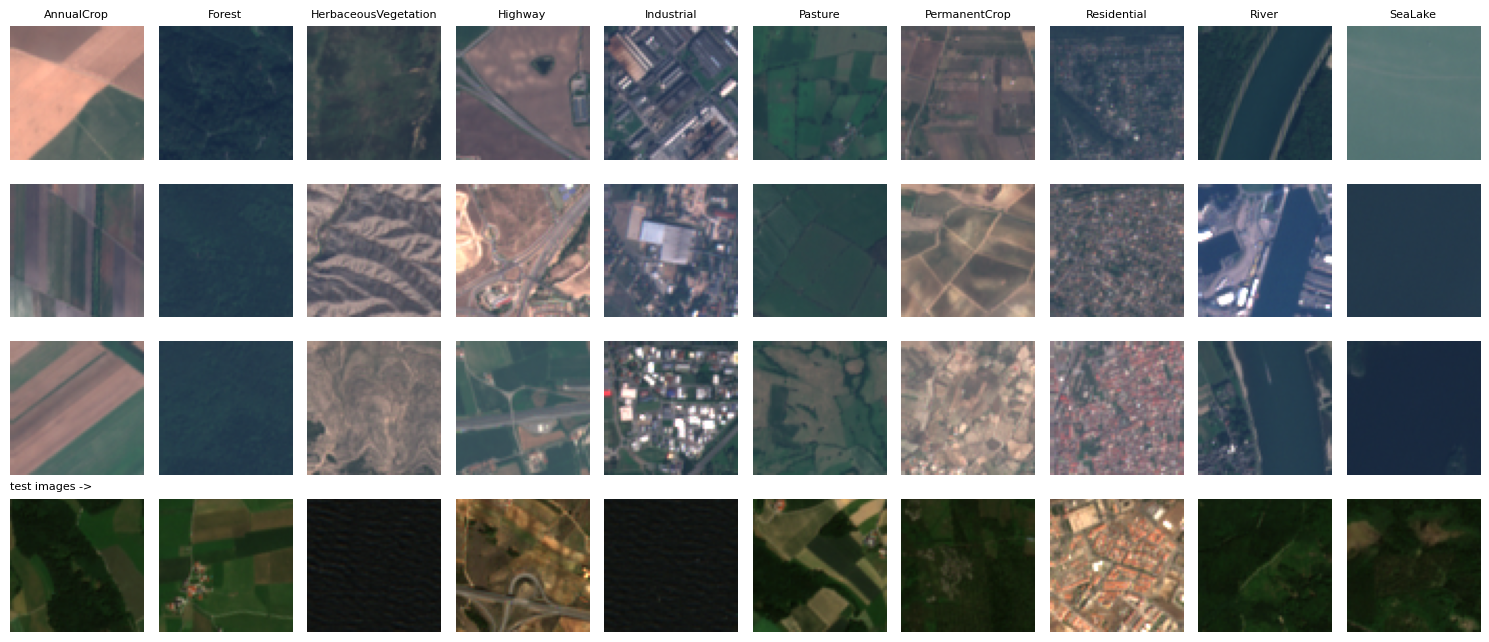

In [ ]:
def normalize_for_display(band_data):
    # From the course's cc_1 notebook: scale each band between its 2nd and 98th percentile (robust to
    # outliers such as reflective roofs). Input is HxWxC.
    band_data = np.array(band_data, dtype=np.float32)
    lower_perc = np.percentile(band_data, 2, axis=(0, 1))
    upper_perc = np.percentile(band_data, 98, axis=(0, 1))
    return (band_data - lower_perc) / np.maximum(upper_perc - lower_perc, 1e-6)   # guard: flat band (e.g. calm water)

def to_rgb(img, band_names):
    # (64, 64, bands) raw image -> (64, 64, 3) displayable picture.
    rgb = img[..., [band_names.index(b) for b in ("B04", "B03", "B02")]]
    return np.clip(normalize_for_display(rgb), 0, 1)   # clip the rare pixels outside the percentile range

fig, axes = plt.subplots(4, 10, figsize=(15, 6.5))
rng = np.random.default_rng(SEED)
for c, name in enumerate(CLASSES):
    for r, i in enumerate(rng.choice(np.where(y == c)[0], 3, replace=False)):
        axes[r, c].imshow(to_rgb(X[i], TRAIN_BANDS)); axes[r, c].axis("off")
    axes[0, c].set_title(name, fontsize=8)
for c, i in enumerate(rng.choice(len(X_test), 10, replace=False)):
    axes[3, c].imshow(to_rgb(X_test[i], TEST_BANDS)); axes[3, c].axis("off")
axes[3, 0].set_title("test images ->", fontsize=8, loc="left")
plt.tight_layout(); plt.show()

## 5. Validation split and normalisation *(guide Steps 3–4)*
- **Split:** 80 % training, 20 % validation, **stratified** (each class keeps its proportion), with a fixed seed so every run and every teammate gets the same split.
- **Normalisation:** per band, subtract the mean and divide by the standard deviation *(guide §2.8)*. Training statistics come from the training part only, estimated on a random sample of 3,000 images to save memory. For test images, `NORM_MODE` decides which statistics are used.

In [ ]:
from sklearn.model_selection import train_test_split

train_idx, val_idx = train_test_split(np.arange(len(y)), test_size=0.2, stratify=y, random_state=SEED)
if SMOKE_TEST:
    train_idx, val_idx = train_idx[:2000], val_idx[:500]
test_idx = np.arange(len(X_test))
print(f"train {len(train_idx)} | val {len(val_idx)} | test {len(test_idx)}")

def band_stats(images, idx, bands, offset=0.0, n=3000):
    # Per-band mean and standard deviation over a random sample of the given images.
    rng = np.random.default_rng(SEED)
    pick = np.sort(rng.choice(idx, size=min(n, len(idx)), replace=False))
    sample = images[pick][..., bands].astype(np.float32) - offset
    return sample.mean(axis=(0, 1, 2)), sample.std(axis=(0, 1, 2)) + 1e-6

TRAIN_MEAN, TRAIN_STD = band_stats(X, train_idx, KEEP_TRAIN)
if NORM_MODE == "separate":
    TEST_MEAN, TEST_STD = band_stats(X_test, test_idx, KEEP_TEST, offset=TEST_OFFSET)
elif NORM_MODE == "train":
    TEST_MEAN, TEST_STD = TRAIN_MEAN, TRAIN_STD
else:
    raise ValueError(NORM_MODE)

train 21600 | val 5400 | test 4232


## 6. Feeding images to PyTorch
A `Dataset` tells PyTorch how to fetch image number *k*: take the raw `uint16` image, select the bands, subtract the offset, standardise, and move the bands to the first axis (PyTorch wants `(bands, 64, 64)`). With `augment=True` it also flips and rotates by a random multiple of 90° *(guide §2.7)*. Converting one image at a time keeps memory low.

A `DataLoader` groups images into mini-batches and shuffles the training set every epoch.

In [ ]:
class EuroSATDataset(Dataset):
    # Serves (image, label) pairs; converts raw uint16 -> standardised float32 tensor per image.
    def __init__(self, images, idx, bands, mean, std, labels=None, offset=0.0,
                 augment=False, radiometric=False):
        self.images, self.idx, self.bands = images, idx, bands
        self.mean, self.std, self.labels, self.offset = mean, std, labels, offset
        self.augment, self.radiometric = augment, radiometric

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, k):
        i = self.idx[k]
        img = (self.images[i][..., self.bands].astype(np.float32) - self.offset - self.mean) / self.std
        img = torch.from_numpy(np.ascontiguousarray(img.transpose(2, 0, 1)))   # -> (bands, 64, 64)
        if self.augment:
            if torch.rand(1).item() < 0.5:
                img = img.flip(2)                                               # mirror
            img = torch.rot90(img, int(torch.randint(4, (1,))), dims=(1, 2))    # 0/90/180/270 degrees
            if self.radiometric:                                                # per-band brightness jitter
                c = img.shape[0]
                img = img * (1 + 0.1 * torch.randn(c, 1, 1)) + 0.1 * torch.randn(c, 1, 1)
        label = -1 if self.labels is None else int(self.labels[i])
        return img, label

# Background worker processes prepare batches while the GPU trains. They must be started with
# "fork" so they share the big image arrays instead of copying them (and so they can see classes
# defined in this notebook). "fork" exists on Linux, which is what Colab runs; elsewhere use 0 workers.
WORKERS = NUM_WORKERS if sys.platform == "linux" else 0

def make_loader(ds, shuffle):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=shuffle,
                      num_workers=WORKERS, multiprocessing_context="fork" if WORKERS > 0 else None,
                      pin_memory=(device == "cuda"), generator=torch.Generator().manual_seed(SEED))

train_ds = EuroSATDataset(X, train_idx, KEEP_TRAIN, TRAIN_MEAN, TRAIN_STD, labels=y,
                          augment=True, radiometric=AUG_RADIOMETRIC)
val_ds   = EuroSATDataset(X, val_idx, KEEP_TRAIN, TRAIN_MEAN, TRAIN_STD, labels=y)
test_ds  = EuroSATDataset(X_test, test_idx, KEEP_TEST, TEST_MEAN, TEST_STD, offset=TEST_OFFSET)
train_loader, val_loader, test_loader = make_loader(train_ds, True), make_loader(val_ds, False), make_loader(test_ds, False)

xb, yb = next(iter(train_loader))
print("one batch:", tuple(xb.shape), xb.dtype, "| mean %.2f, std %.2f" % (xb.mean(), xb.std()))  # CHECK: ~0 and ~1

one batch: (128, 12, 64, 64) torch.float32 | mean -0.05, std 0.97


## 7. The model *(guide §2.5, Step 6)*
A small CNN built from four **blocks**. Each block has one or two 3×3 convolutions, each followed by BatchNorm and ReLU, and ends with a max-pooling step that halves height and width:

`12×64×64 → 32×32×32 → 64×16×16 → 128×8×8 → 256×4×4 → global average pool (256) → dropout → linear → 10 scores`

The next cell prints the parameter count and **stops if it exceeds 1,000,000**. The TAs check this number, so keep this cell in your final notebook. The cell after it defines the prediction helpers used in Sections 10, 11 and 13.

In [ ]:
def conv_block(c_in, c_out, n_convs):
    # n_convs x (3x3 conv -> BatchNorm -> ReLU), then 2x2 max-pooling.
    layers = []
    for k in range(n_convs):
        layers += [nn.Conv2d(c_in if k == 0 else c_out, c_out, kernel_size=3, padding=1, bias=False),
                   nn.BatchNorm2d(c_out), nn.ReLU(inplace=True)]
    layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)

class SmallCNN(nn.Module):
    # Conv blocks (each halves height/width) -> global average pooling -> dropout -> linear head.
    def __init__(self, in_bands, n_classes=10, widths=WIDTHS, convs=CONVS, dropout=DROPOUT):
        super().__init__()
        blocks, c = [], in_bands
        for w, n in zip(widths, convs):
            blocks.append(conv_block(c, w, n))
            c = w
        self.features = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(dropout), nn.Linear(c, n_classes))

    def forward(self, x):
        return self.head(self.pool(self.features(x)))   # raw class scores (logits)

def count_params(model):
    return sum(p.numel() for p in model.parameters())   # all parameters, trainable or not

model = SmallCNN(in_bands=len(USE_BANDS)).to(device)
N_PARAMS = count_params(model)
print(f"{N_PARAMS:,} parameters")
assert N_PARAMS <= 1_000_000, "too many parameters for the small track"
print("output shape for 2 images:", tuple(model(torch.zeros(2, len(USE_BANDS), 64, 64, device=device)).shape))

588,042 parameters
output shape for 2 images: (2, 10)


In [ ]:
# Prediction helpers used in Sections 10, 11 and 13. They are defined here, before any training,
# so that Section 13 also works in a fresh session.
def predict_proba(model, loader, tta=False):
    # Class probabilities for every image in `loader` (optionally averaged over 8 flips/rotations).
    model.eval()                                  # evaluation mode: dropout off, BatchNorm frozen
    out = []
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            views = [xb] if not tta else [torch.rot90(v, k, dims=(2, 3)) for v in (xb, xb.flip(3)) for k in range(4)]
            out.append(torch.stack([model(v).softmax(1) for v in views]).mean(0).cpu())
    return torch.cat(out).numpy()

def make_submission(model, loader, tta):
    # DataFrame with columns test_id,label for every test image, sorted by id.
    pred = predict_proba(model, loader, tta=tta).argmax(1)
    return (pd.DataFrame({"test_id": test_ids, "label": [CLASSES[i] for i in pred]})
              .sort_values("test_id").reset_index(drop=True))

## 8. Training *(guide §2.3–2.4)*
- `run_epoch` makes one pass over the data. With an optimizer it **trains**: forward pass → loss → gradients → update. Without one it only **measures**.
- `fit` repeats this for all epochs:
  - It uses the **AdamW** optimiser (Adam with weight decay).
  - The learning rate slowly decreases along a cosine curve.
  - After every epoch it measures the validation set and **saves the weights whenever the validation accuracy is the best so far**. That saved file is your model, even if later epochs overfit.

Each run gets its own folder on Drive, `eurosat/runs/<RUN_NAME>/`, holding the config, the weights, the history, the plots and the CSV.

In [ ]:
def run_epoch(model, loader, loss_fn, optimizer=None):
    # One pass over `loader`; trains if an optimizer is given. Returns (mean loss, accuracy).
    training = optimizer is not None
    model.train(training)                       # train mode: dropout on, BatchNorm updates
    total_loss, correct, seen = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
            seen += len(yb)
    return total_loss / seen, correct / seen

def fit(model, epochs, ckpt_path):
    # Train for `epochs`, keep the weights with the best validation accuracy. Returns the history.
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history, best = [], -1.0
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, loss_fn, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, loss_fn)
        scheduler.step()
        history.append(dict(epoch=epoch, train_loss=tr_loss, train_acc=tr_acc, val_loss=va_loss, val_acc=va_acc))
        note = ""
        if va_acc > best:
            best = va_acc
            torch.save(model.state_dict(), ckpt_path)
            note = "  <- best so far, saved"
        print(f"epoch {epoch:2d} | train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
              f"val loss {va_loss:.3f} acc {va_acc:.3f} | {time.time() - t0:.0f}s{note}")
    return pd.DataFrame(history)

In [ ]:
RUN_DIR = DATA_DIR / "runs" / RUN_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)
CKPT = RUN_DIR / "small_best.pt"

config = dict(RUN_NAME=RUN_NAME, SEED=SEED, TEST_BANDS=TEST_BANDS, USE_BANDS=USE_BANDS,
              NORM_MODE=NORM_MODE, TEST_OFFSET=TEST_OFFSET, WIDTHS=WIDTHS, CONVS=CONVS,
              DROPOUT=DROPOUT, EPOCHS=EPOCHS, BATCH_SIZE=BATCH_SIZE, LR=LR, WEIGHT_DECAY=WEIGHT_DECAY,
              AUG_RADIOMETRIC=AUG_RADIOMETRIC, USE_TTA=USE_TTA, SMOKE_TEST=SMOKE_TEST, N_PARAMS=N_PARAMS)
(RUN_DIR / "config.json").write_text(json.dumps(config, indent=2))
save_npz(RUN_DIR / "norm_stats.npz", train_mean=TRAIN_MEAN, train_std=TRAIN_STD,
         test_mean=TEST_MEAN, test_std=TEST_STD)             # needed to reproduce the CSV later

set_seed(SEED)
model = SmallCNN(in_bands=len(USE_BANDS)).to(device)
history = fit(model, epochs=2 if SMOKE_TEST else EPOCHS, ckpt_path=CKPT)
history.to_csv(RUN_DIR / "history.csv", index=False)

epoch  1 | train loss 0.505 acc 0.832 | val loss 0.306 acc 0.905 | 18s  <- best so far, saved
epoch  2 | train loss 0.264 acc 0.916 | val loss 0.311 acc 0.902 | 19s
epoch  3 | train loss 0.217 acc 0.928 | val loss 0.156 acc 0.948 | 17s  <- best so far, saved
epoch  4 | train loss 0.183 acc 0.941 | val loss 0.143 acc 0.953 | 17s  <- best so far, saved
epoch  5 | train loss 0.164 acc 0.949 | val loss 0.155 acc 0.951 | 17s
epoch  6 | train loss 0.149 acc 0.952 | val loss 0.129 acc 0.954 | 18s  <- best so far, saved
epoch  7 | train loss 0.150 acc 0.950 | val loss 0.131 acc 0.957 | 18s  <- best so far, saved
epoch  8 | train loss 0.127 acc 0.957 | val loss 0.115 acc 0.962 | 17s  <- best so far, saved
epoch  9 | train loss 0.115 acc 0.962 | val loss 0.108 acc 0.962 | 17s  <- best so far, saved
epoch 10 | train loss 0.109 acc 0.963 | val loss 0.099 acc 0.967 | 17s  <- best so far, saved
epoch 11 | train loss 0.099 acc 0.967 | val loss 0.123 acc 0.958 | 17s
epoch 12 | train loss 0.104 acc 0.9

## 9. Training curves *(guide §2.4)*
**CHECK:** the training loss should go down. If the training accuracy keeps climbing while the validation accuracy stalls or drops, the model is overfitting *(guide Figure 6)*. The rubric asks for this plot for both tracks.

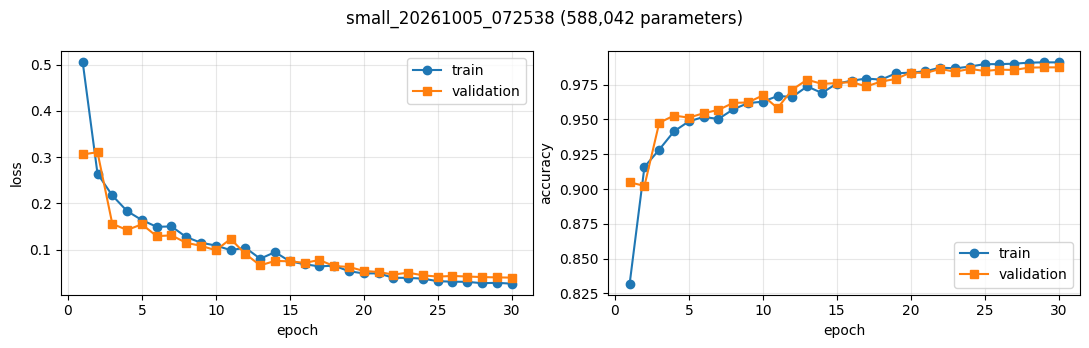

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.plot(history.epoch, history.train_loss, "o-", label="train"); ax1.plot(history.epoch, history.val_loss, "s-", label="validation")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(history.epoch, history.train_acc, "o-", label="train"); ax2.plot(history.epoch, history.val_acc, "s-", label="validation")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.legend(); ax2.grid(alpha=0.3)
fig.suptitle(f"{RUN_NAME} ({N_PARAMS:,} parameters)")
plt.tight_layout(); fig.savefig(RUN_DIR / "curves.png", dpi=150); plt.show()

## 10. Validation accuracy and confusion matrix *(guide §2.9)*
This loads the **best** saved weights, not the last epoch's. `predict_proba` switches the model to evaluation mode, which is essential *(guide pitfall 6)*. With `USE_TTA` it averages the predictions over the 8 flipped/rotated versions of each image.

Accuracy, the per-class report and the confusion matrix use the Lab 2 tools (`metrics.accuracy_score`, `classification_report`, `confusion_matrix` drawn with `sns.heatmap`). As in Lab 2 the matrix is transposed: **true** labels on the x-axis, **predicted** labels on the y-axis.

**CHECK** which classes get mixed up. That is useful material for your slides.

validation accuracy (best checkpoint, TTA): 0.9874


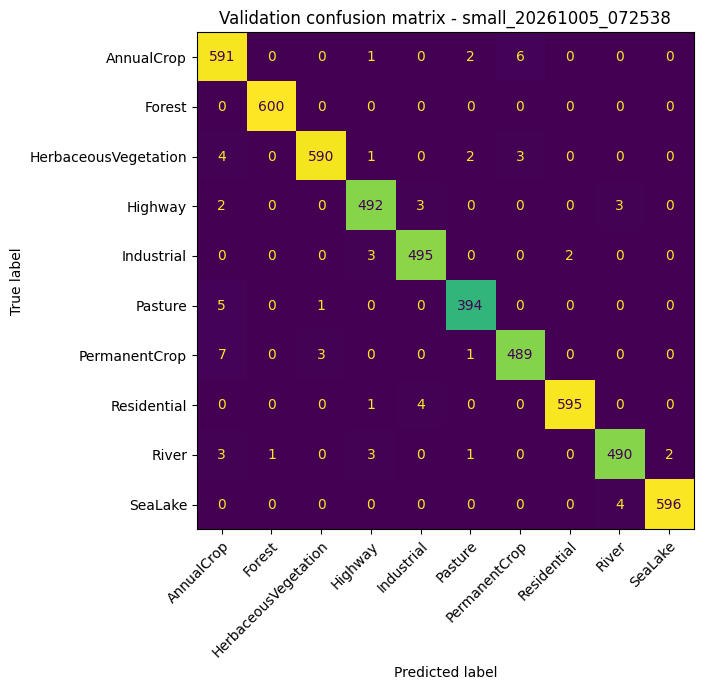

In [ ]:
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.load_state_dict(torch.load(CKPT, map_location=device))
val_pred = predict_proba(model, val_loader, tta=USE_TTA).argmax(1)
val_true = y[val_idx]
VAL_ACC = metrics.accuracy_score(val_true, val_pred)
print(f"validation accuracy (best checkpoint{', TTA' if USE_TTA else ''}): {VAL_ACC:.4f}")
print(classification_report(val_true, val_pred, labels=range(len(CLASSES)), target_names=CLASSES, digits=3))

# Drawn as in Lab 2: transposed, true labels on the x-axis, predicted labels on the y-axis.
mat = confusion_matrix(val_true, val_pred, labels=range(len(CLASSES)))
fig = plt.figure(figsize=(8, 7))
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False, cmap='BuGn_r', xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel('[true class label $y_{i}$]')
plt.ylabel('[predicted class label $y_{i}\'$]')
plt.xticks(rotation=45, ha="right")                                  # keep long names readable
plt.title(f"Validation confusion matrix - {RUN_NAME}")
plt.tight_layout(); fig.savefig(RUN_DIR / "confusion_matrix.png", dpi=150); plt.show()

## 11. Predict the test set and write the submission CSV *(guide Step 9)*
It translates label numbers back into class names with the **same** `CLASSES` list used in training, sorts by `test_id`, and compares the file with `sample_submission.csv`. The asserts stop the cell if anything is off.

**CHECK** the predicted class counts. If almost everything goes to one or two classes, something is wrong, e.g. the band order or the normalisation of the test data.

In [ ]:
sub = make_submission(model, test_loader, USE_TTA)

sample_path = DATA_DIR / "sample_submission.csv"
if sample_path.exists():
    sample = pd.read_csv(sample_path)
    assert list(sub.columns) == list(sample.columns), (list(sub.columns), list(sample.columns))
    assert len(sub) == len(sample) and set(sub.test_id) == set(sample.test_id), "ids do not match the sample"
    print("format matches sample_submission.csv")
else:
    print("WARNING: sample_submission.csv not found - compare the format by hand")
assert set(sub.label) <= set(CLASSES)

SUB_PATH = RUN_DIR / "submission_small.csv"
sub.to_csv(SUB_PATH, index=False)
print("saved", SUB_PATH)
print(sub.label.value_counts())

format matches sample_submission.csv
saved /content/drive/MyDrive/eurosat/runs/small_20261005_072538/submission_small.csv
label
HerbaceousVegetation    3918
Residential              275
Industrial                28
Highway                    7
Forest                     4
Name: count, dtype: int64


## 12. Submit to Kaggle and log the experiment *(guide Step 8)*
Set `SUBMIT = True` and run the cell to upload. The message records the track and the settings, which is how you'll tell your small-track and medium-track submissions apart later. Smoke-test runs are never submitted. Mind the daily submission limit.

Every run also gets a line in `eurosat/experiment_log.csv` on Drive. Add the Kaggle score by hand once you see it on the leaderboard.

In [ ]:
SUBMIT = True   # set True to upload this run's CSV

if SUBMIT and SMOKE_TEST:
    print("this is a smoke-test run - not submitting")
elif SUBMIT:
    setup_kaggle()
    msg = (f"small track | {RUN_NAME} | {N_PARAMS:,} params | norm={NORM_MODE} | "
           f"bands={len(USE_BANDS)} | tta={USE_TTA} | val_acc={VAL_ACC:.4f}")
    kaggle("competitions", "submit", "-c", COMPETITION, "-f", str(SUB_PATH), "-m", msg)

log_path = DATA_DIR / "experiment_log.csv"
row = {**{k: str(v) for k, v in config.items()}, "best_val_acc": round(float(history.val_acc.max()), 4),
       "val_acc_final": round(float(VAL_ACC), 4), "submitted": bool(SUBMIT and not SMOKE_TEST), "kaggle_public": ""}
pd.DataFrame([row]).to_csv(log_path, mode="a", header=not log_path.exists(), index=False)
print("logged to", log_path)

14 submissions remaining today.
Successfully submitted to 7,854,1.00: Machine Learning 2026 - Coding challenge 
  0%|          | 0.00/104k [00:00<?, ?B/s]
100%|██████████| 104k/104k [00:00<00:00, 440kB/s]

logged to /content/drive/MyDrive/eurosat/experiment_log.csv


## 13. Reproduce a submission from saved weights *(rubric: "code reproduces csv file")*
This rebuilds the CSV of any finished run from its saved files alone: `config.json`, `norm_stats.npz` and `small_best.pt`. It then compares the result with the CSV that was saved at the time. Point `REPRO_RUN` at the run you submitted.

In a fresh session, run Sections 0–7 first (no training needed) and set `REPRO_RUN` to the run's folder. It needs nothing from Sections 8–12.

In [ ]:
def reproduce_submission(run_dir):
    # Rebuild a run's test predictions from its saved config, statistics and weights.
    cfg = json.loads((run_dir / "config.json").read_text())
    stats = np.load(run_dir / "norm_stats.npz")
    keep = [TEST_BANDS.index(b) for b in cfg["USE_BANDS"]]
    ds = EuroSATDataset(X_test, np.arange(len(X_test)), keep, stats["test_mean"], stats["test_std"],
                        offset=cfg["TEST_OFFSET"])
    m = SmallCNN(in_bands=len(keep), widths=tuple(cfg["WIDTHS"]), convs=tuple(cfg["CONVS"]),
                 dropout=cfg["DROPOUT"]).to(device)
    m.load_state_dict(torch.load(run_dir / "small_best.pt", map_location=device))
    print(f"{count_params(m):,} parameters")
    return make_submission(m, make_loader(ds, False), cfg["USE_TTA"])

REPRO_RUN = RUN_DIR   # e.g. DATA_DIR / "runs" / "small_20261020_143000"
again = reproduce_submission(REPRO_RUN)
saved = pd.read_csv(REPRO_RUN / "submission_small.csv")
print("identical to the saved CSV:", again.equals(saved), f"({(again.label != saved.label).sum()} labels differ)")

## 14. What to try next *(guide Step 8)*
Change **one** setting in Section 3, run everything again, and compare runs in `experiment_log.csv`: validation accuracy *and* Kaggle score. Suggested order:

1. **A real run.** Set `SMOKE_TEST = False`, then submit. This is your baseline.
2. **`NORM_MODE = "separate"`.** Probably the cheapest way to reduce the domain shift. Compare the Kaggle scores of 1 and 2.
3. **`TEST_OFFSET = 1000`**, but only if the statistics in Section 4 showed the offset.
4. **`AUG_RADIOMETRIC = True`**, which teaches the model to ignore moderate brightness changes.
5. **Fewer bands.** Remove bands the atmosphere affects most, e.g. `USE_BANDS = [b for b in TEST_BANDS if b not in ("B01", "B09")]`.
6. **Learning rate and epochs.** Try `LR` of 3e-3 and 3e-4, and `EPOCHS` of 50.
7. **Model width.** Try different `WIDTHS`/`CONVS`; the assert in Section 7 stops you above 1M parameters.

Keep in mind that validation accuracy cannot see the domain shift: validation images are EuroSAT like the training data. Only the Kaggle score tells you whether a change helps on the test data.